In [2]:

import numpy as np
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
# from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
# from astropy.wcs import utils as asutils
# from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, gaussian
# from skimage.io import imread, imshow
# from skimage.feature import peak_local_max
# from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

ROI center 6, 0
ROI center in Galactic Coordintes = 6, 0
Loading Galactic Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-AIT' 'GLAT-AIT' 
CRVAL : 6.0 0.0 
CRPIX : 1800.0 720.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 3600  1440
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Shape of Map in pixel number: 1440 X 3600
Degrees per pixel: 0.005555555555555556 
Peak intensity pixel location: (725, 559)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (12.88992755, 0.03331827)>
Peak intensity value: 43.93085533617096
None
Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (725, 559)
Peak intensity sky location: <SkyCoord (Galactic): (l, b) in deg
    (12.88992755, 0.03331827)>
Peak intensity value: 43.93085533617096


(269.81677533218704, -23.772348107552983)

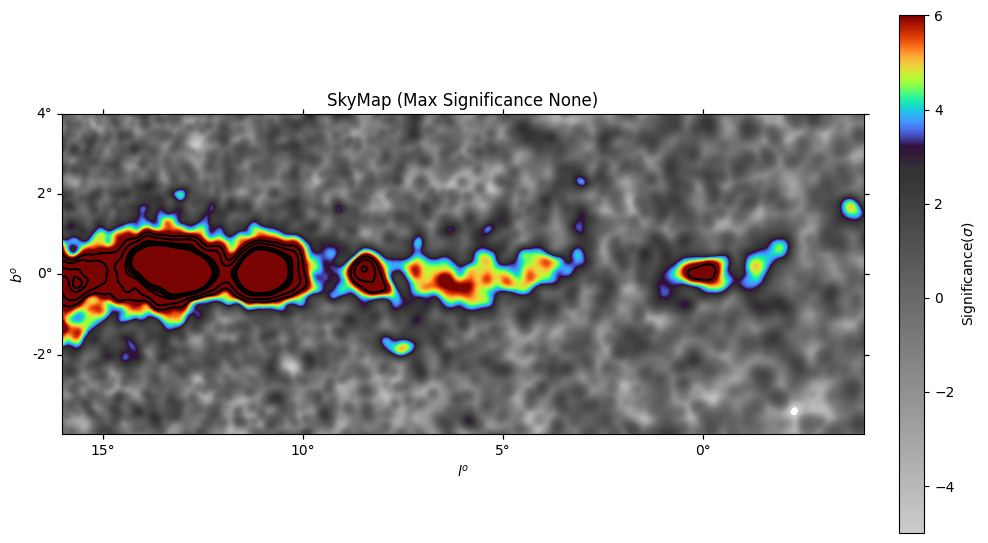

In [3]:
# Load the Simulation FITS file
filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
outdir = os.getcwd()+ '/galactic_plane_plots/'
if not os.path.exists(outdir):
    print("Creating output directory for plots")
    os.makedirs(outdir)



ra_center = 6
dec_center = 0
coord_sys = 'G'
xlength=10
ylength=4


# ra_center = 83.5
# dec_center = 22
# coord_sys = 'C'
# xlength=7
# ylength=7

save_pdf = False
if save_pdf:
    pdf = PdfPages(os.path.join(outdir, f'run-{ra_center}-{dec_center}-plots.pdf'))
print(f"ROI center {ra_center}, {dec_center}")

 

array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, ra_center, dec_center, xlength, ylength, coord_sys)
print(f'Shape of Map in pixel number: {ynum} X {xnum}')
print(f'Degrees per pixel: {pixel_size} ')
max_signif=find_peak(array, wcs)
print(max_signif)
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title=f'SkyMap (Max Significance {max_signif})', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  
find_peak(array, wcs)
gal_to_cel(ra_center, dec_center)


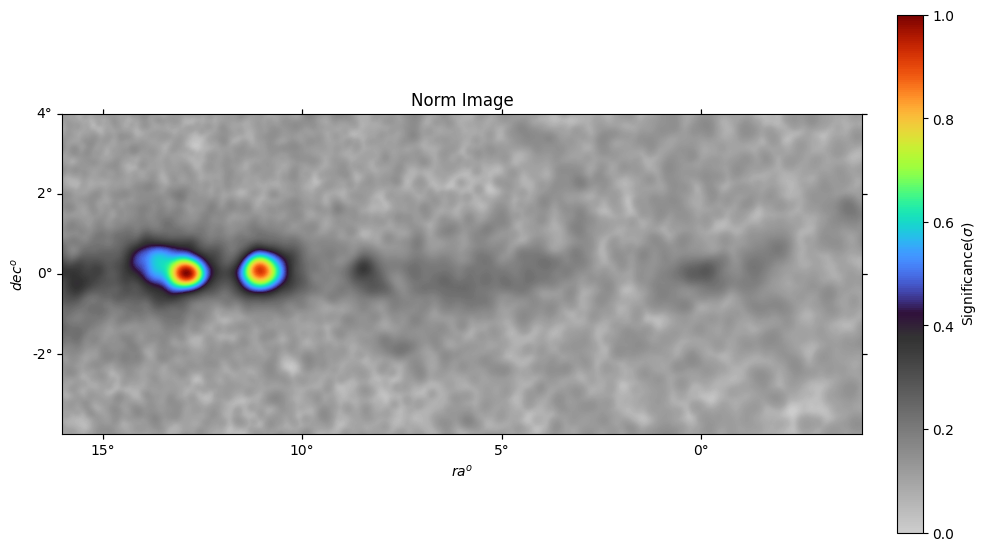

In [4]:
# #Normalize the image between 0 and 1 for analysis
image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title='Norm Image', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))
if save_pdf:
    pdf.savefig(fig) 


Pixel Size = 0.0056°

Processing smear radius: 0.15°
Number of pixels: 27.00
Estimated background RMS: 0.009766
Point source blobs detected: 18
Blob Intensity 42.862495656425715, Coords (273.37467699394904 deg, -17.79450788758014 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 38.96417413188284, Coords (272.3597045973192 deg, -19.269554410481373 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 11.909495309549257, Coords (270.9668907063199 deg, -21.53806404696872 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 22.201837690792033, Coords (273.3419778125869 deg, -16.878083079717754 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 8.316723464430257, Coords (266.2200555228313 deg, -28.987873738612404 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 12.941891011833006, Coords (275.0720010762001 deg, -15.519785683550408 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 17.07275871656471, Coords (273.6348671571542 deg, -16.46759821552675 deg), Radius 18.0, Pixel Radius 0.1
After i

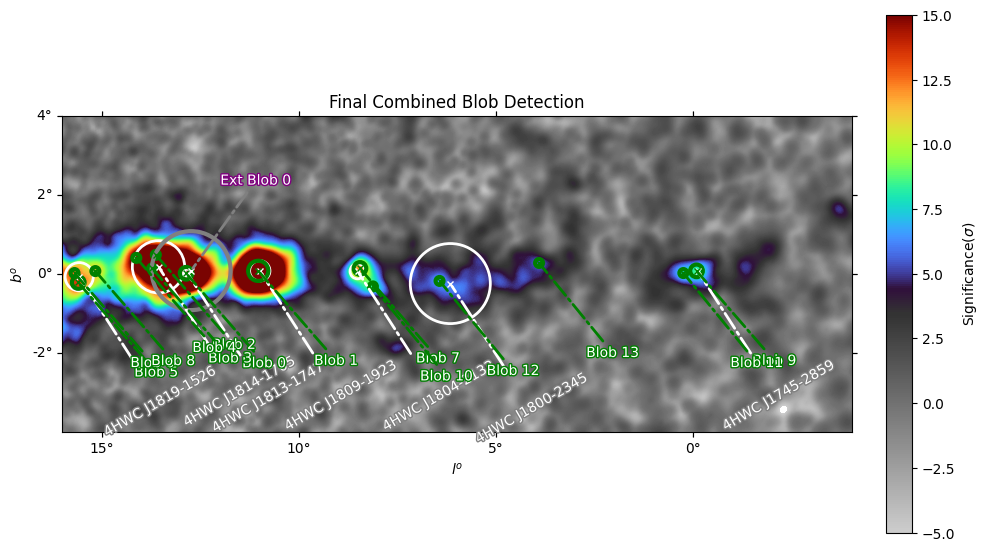

In [5]:
"""
Enhanced blob detection for gamma-ray sky maps with improved deduplication
"""

import numpy as np
from scipy.spatial.distance import cdist
from skimage.feature import blob_dog
from skimage.filters import difference_of_gaussians
import scipy.ndimage as ndi
from astropy.stats import sigma_clip

def estimate_background_sigma(image, sigma=3, maxiters=5):
    """Estimate background RMS using sigma clipping"""
    clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
    return np.std(clipped.data[~clipped.mask])

def remove_overlapping_blobs(blobs, coords, radii, significances=None, 
                            overlap_threshold=0.5, separation_factor=1.5):
    """
    Remove overlapping blobs with improved logic.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values
    significances : list of float, optional
        Peak significance values for each blob
    overlap_threshold : float
        Fraction of overlap to consider blobs as duplicates
    separation_factor : float
        Multiplier for maximum separation (in units of larger radius)
    
    Returns:
    --------
    filtered_blobs, filtered_coords, filtered_radii, [filtered_sigs]
    """
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    # Sort by significance if available, otherwise by radius (descending)
    if significances is not None:
        sorted_indices = np.argsort(significances)[::-1]
        sorted_sigs = [significances[i] for i in sorted_indices]
    else:
        sorted_indices = np.argsort(blobs[:, 2])[::-1]
        sorted_sigs = None
    
    sorted_blobs = blobs[sorted_indices]
    sorted_coords = [coords[i] for i in sorted_indices]
    sorted_radii = [radii[i] for i in sorted_indices]
    
    keep_mask = np.ones(len(sorted_blobs), dtype=bool)
    
    for i in range(len(sorted_blobs)):
        if not keep_mask[i]:
            continue
        
        # Calculate distance to all other blobs
        distances = np.sqrt((sorted_blobs[i, 0] - sorted_blobs[:, 0])**2 + 
                          (sorted_blobs[i, 1] - sorted_blobs[:, 1])**2)
        
        # Check for overlap (geometric overlap)
        radii_sum = sorted_blobs[i, 2] + sorted_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        
        # Also check proximity (catches same source at different scales)
        max_radius = np.maximum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        is_nearby = distances < separation_factor * max_radius
        
        # Mark as duplicate if either overlapping OR nearby
        is_duplicate = (overlap > overlap_threshold) | is_nearby
        
        keep_mask[is_duplicate] = False
        keep_mask[i] = True  # Always keep current blob
    
    # Filter all arrays/lists
    filtered_blobs = sorted_blobs[keep_mask]
    filtered_coords = [coord for i, coord in enumerate(sorted_coords) if keep_mask[i]]
    filtered_radii = [radius for i, radius in enumerate(sorted_radii) if keep_mask[i]]
    
    if sorted_sigs is not None:
        filtered_sigs = [sig for i, sig in enumerate(sorted_sigs) if keep_mask[i]]
        return filtered_blobs, filtered_coords, filtered_radii, filtered_sigs
    
    return filtered_blobs, filtered_coords, filtered_radii


def multi_scale_blob_detection(norm_image, array, wcs, pixel_size, 
                               radii_range=None, detect_extended=False,
                               ps_threshold=0.01, ext_threshold=None,
                               min_intensity=5):
    """
    Perform multi-scale blob detection on gamma-ray significance map.
    
    Parameters:
    -----------
    norm_image : 2D array
        Normalized significance map
    array : 2D array
        Original (unnormalized) significance map
    wcs : WCS object
        World coordinate system
    pixel_size : float
        Pixel size in degrees
    radii_range : list of float, optional
        PSF radii to test (in degrees). Default: [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    detect_extended : bool
        Whether to also detect extended sources
    ps_threshold : float
        Threshold for point source detection
    ext_threshold : float, optional
        Threshold for extended source detection (default: 0.7 * ps_threshold)
    min_intensity : float
        Minimum peak significance for blob filtering
    
    Returns:
    --------
    results : dict
        Dictionary containing final point source and extended source detections
    """
    
    if radii_range is None:
        radii_range = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    
    if ext_threshold is None:
        ext_threshold = 0.7 * ps_threshold
    
    # Storage for all detections
    all_ps_blobs = []
    all_pscoord_blobs = []
    all_psradius_blobs = []
    all_pssig_blobs = []
    
    all_ext_blobs = []
    all_extcoord_blobs = []
    all_extradius_blobs = []
    all_extsig_blobs = []
    
    print(f"Pixel Size = {pixel_size:.4f}°")
    
    for smear_radius in radii_range:
        print(f"\n{'='*60}")
        print(f"Processing smear radius: {smear_radius:.2f}°")
        print(f"Number of pixels: {smear_radius/pixel_size:.2f}")
        
        # Difference of Gaussians
        dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
        dog_low_noise = ndi.gaussian_filter(dog_image, sigma=1.0)
        
        # Estimate background
        sigma_resid = estimate_background_sigma(dog_image)
        print(f"Estimated background RMS: {sigma_resid:.6f}")
        
        dog_final = np.where(dog_low_noise > 2 * sigma_resid, dog_low_noise, 0)
        
        # Point source detection
        # Use smear_radius as max_sigma for scale-appropriate detection
        ps_blobs = blob_dog(dog_final, 
                           min_sigma=0.1/pixel_size,
                           max_sigma=smear_radius/pixel_size,  # Scale-dependent!
                           threshold=ps_threshold,
                           exclude_border=50,
                           overlap=0.5)
        
        print(f"Point source blobs detected: {len(ps_blobs)}")
        
        if len(ps_blobs) > 0:
            # Filter by intensity and extract coordinates
            ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = \
                blob_filter_intensity(ps_blobs, array, min_intensity, wcs, pixel_size)
            
            # Extract peak significances
            ps_sigs = []
            for blob in ps_filtered_blobs:
                y, x, r = blob
                peak_sig = array[int(y), int(x)]
                ps_sigs.append(peak_sig)
            
            if len(ps_filtered_blobs) > 0:
                all_ps_blobs.append(ps_filtered_blobs)
                all_pscoord_blobs.append(ps_filtered_coords)
                all_psradius_blobs.append(ps_filtered_radius)
                all_pssig_blobs.append(ps_sigs)
                print(f"After intensity filter: {len(ps_filtered_blobs)} point sources")
        
        # Extended source detection (optional)
        if detect_extended:
            ext_blobs = blob_dog(dog_final,
                               min_sigma=1.0/pixel_size,
                               max_sigma=2.0/pixel_size,
                               threshold=ext_threshold,
                               exclude_border=50,
                               overlap=0.5)
            
            print(f"Extended source blobs detected: {len(ext_blobs)}")
            
            if len(ext_blobs) > 0:
                ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = \
                    blob_filter_intensity(ext_blobs, array, min_intensity*0.6, wcs, pixel_size)
                
                ext_sigs = []
                for blob in ext_filtered_blobs:
                    y, x, r = blob
                    peak_sig = array[int(y), int(x)]
                    ext_sigs.append(peak_sig)
                
                if len(ext_filtered_blobs) > 0:
                    all_ext_blobs.append(ext_filtered_blobs)
                    all_extcoord_blobs.append(ext_filtered_coords)
                    all_extradius_blobs.append(ext_filtered_radius)
                    all_extsig_blobs.append(ext_sigs)
                    print(f"After intensity filter: {len(ext_filtered_blobs)} extended sources")
    
    # Combine and deduplicate point sources
    print(f"\n{'='*60}")
    print("COMBINING AND DEDUPLICATING DETECTIONS")
    print(f"{'='*60}")
    
    if len(all_ps_blobs) > 0:
        combined_ps_blobs = np.vstack(all_ps_blobs)
        combined_pscoord_blobs = [coord for sublist in all_pscoord_blobs for coord in sublist]
        combined_psradius_blobs = [radius for sublist in all_psradius_blobs for radius in sublist]
        combined_pssig_blobs = [sig for sublist in all_pssig_blobs for sig in sublist]
        
        print(f"Total point source detections before deduplication: {len(combined_ps_blobs)}")
        
        # Remove overlaps (using significance for prioritization)
        final_ps_blobs, final_pscoords_blobs, final_psradius_blobs, final_pssig_blobs = \
            remove_overlapping_blobs(combined_ps_blobs, combined_pscoord_blobs, 
                                    combined_psradius_blobs, combined_pssig_blobs,
                                    overlap_threshold=0.5, separation_factor=1.5)
        
        print(f"Final point sources after deduplication: {len(final_ps_blobs)}")
    else:
        final_ps_blobs = np.array([]).reshape(0, 3)
        final_pscoords_blobs = []
        final_psradius_blobs = []
        final_pssig_blobs = []
        print("No point sources detected")
    
    # Combine and deduplicate extended sources
    if detect_extended and len(all_ext_blobs) > 0:
        combined_ext_blobs = np.vstack(all_ext_blobs)
        combined_extcoord_blobs = [coord for sublist in all_extcoord_blobs for coord in sublist]
        combined_extradius_blobs = [radius for sublist in all_extradius_blobs for radius in sublist]
        combined_extsig_blobs = [sig for sublist in all_extsig_blobs for sig in sublist]
        
        print(f"Total extended source detections before deduplication: {len(combined_ext_blobs)}")
        
        final_ext_blobs, final_extcoords_blobs, final_extradius_blobs, final_extsig_blobs = \
            remove_overlapping_blobs(combined_ext_blobs, combined_extcoord_blobs,
                                    combined_extradius_blobs, combined_extsig_blobs,
                                    overlap_threshold=0.3, separation_factor=2.0)
        
        print(f"Final extended sources after deduplication: {len(final_ext_blobs)}")
    else:
        final_ext_blobs = np.array([]).reshape(0, 3)
        final_extcoords_blobs = []
        final_extradius_blobs = []
        final_extsig_blobs = []
        if detect_extended:
            print("No extended sources detected")
    
    return {
        'ps_blobs': final_ps_blobs,
        'ps_coords': final_pscoords_blobs,
        'ps_radii': final_psradius_blobs,
        'ps_significances': final_pssig_blobs,
        'ext_blobs': final_ext_blobs,
        'ext_coords': final_extcoords_blobs,
        'ext_radii': final_extradius_blobs,
        'ext_significances': final_extsig_blobs
    }


# Example usage:

# Assuming you have: norm_image, array, wcs, pixel_size defined
# and blob_filter_intensity function available

results = multi_scale_blob_detection(
    norm_image, 
    array, 
    wcs, 
    pixel_size,
    radii_range=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    detect_extended=True,
    ps_threshold=0.01,
    min_intensity=5
)

# Access results
final_ps_blobs = results['ps_blobs']
final_ps_coords = results['ps_coords']
final_ps_sigs = results['ps_significances']

# Plot if blobs found
if len(final_ps_blobs) > 0:
    blobs_dict = {'psblobs': final_ps_blobs}
    if len(results['ext_blobs']) > 0:
        blobs_dict['extblobs'] = results['ext_blobs']
    
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', 
                        blobs=blobs_dict,
                        title='Final Combined Blob Detection', 
                        cmap='ult', labels=['4hawc'])

In [ ]:
"""
Strategies to prevent blob fragmentation in gamma-ray source detection
"""

import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform

def merge_fragmented_blobs(blobs, coords, radii, significances=None, 
                          merge_distance_factor=2.0, method='average'):
    """
    Merge blobs that are likely fragments of the same source using hierarchical clustering.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values
    significances : list of float, optional
        Peak significance values
    merge_distance_factor : float
        Blobs within this factor × (sum of radii) are merged
    method : str
        Clustering linkage method ('single', 'average', 'complete')
    
    Returns:
    --------
    merged_blobs, merged_coords, merged_radii, [merged_sigs]
    """
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    if len(blobs) == 1:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append(significances)
        return tuple(return_vals)
    
    # Calculate pairwise distances
    positions = blobs[:, :2]  # [y, x] positions
    distances = squareform(pdist(positions))
    
    # Create distance threshold matrix based on blob sizes
    radii_array = blobs[:, 2]
    radii_sum = radii_array[:, np.newaxis] + radii_array[np.newaxis, :]
    threshold_matrix = merge_distance_factor * radii_sum
    
    # Identify which blobs should be merged (distance < threshold)
    should_merge = distances < threshold_matrix
    np.fill_diagonal(should_merge, False)  # Don't merge with self
    
    # Use connected components to find groups
    n_blobs = len(blobs)
    blob_groups = list(range(n_blobs))  # Initially each blob is its own group
    
    # Union-find to group connected blobs
    def find_root(i, blob_groups):
        while blob_groups[i] != i:
            blob_groups[i] = blob_groups[blob_groups[i]]  # Path compression
            i = blob_groups[i]
        return i
    
    def union(i, j, blob_groups):
        root_i = find_root(i, blob_groups)
        root_j = find_root(j, blob_groups)
        if root_i != root_j:
            blob_groups[root_j] = root_i
    
    # Group blobs that should be merged
    for i in range(n_blobs):
        for j in range(i + 1, n_blobs):
            if should_merge[i, j]:
                union(i, j, blob_groups)
    
    # Find unique groups
    groups = {}
    for i in range(n_blobs):
        root = find_root(i, blob_groups)
        if root not in groups:
            groups[root] = []
        groups[root].append(i)
    
    # Merge blobs within each group
    merged_blobs = []
    merged_coords = []
    merged_radii = []
    merged_sigs = [] if significances is not None else None
    
    for group_indices in groups.values():
        if len(group_indices) == 1:
            # Single blob - keep as is
            idx = group_indices[0]
            merged_blobs.append(blobs[idx])
            merged_coords.append(coords[idx])
            merged_radii.append(radii[idx])
            if significances is not None:
                merged_sigs.append(significances[idx])
        else:
            # Multiple blobs - merge them
            group_blobs = blobs[group_indices]
            group_radii = [radii[i] for i in group_indices]
            group_coords = [coords[i] for i in group_indices]
            
            if significances is not None:
                group_sigs = [significances[i] for i in group_indices]
                # Use significance-weighted centroid
                weights = np.array(group_sigs)
                weights = weights / weights.sum()
                
                merged_y = np.sum(group_blobs[:, 0] * weights)
                merged_x = np.sum(group_blobs[:, 1] * weights)
                merged_r = np.max(group_radii)  # Use largest radius
                merged_sig = np.max(group_sigs)  # Use highest significance
                
                # Use coordinate of most significant blob
                max_sig_idx = group_indices[np.argmax(group_sigs)]
                merged_coord = coords[max_sig_idx]
            else:
                # Simple centroid
                merged_y = np.mean(group_blobs[:, 0])
                merged_x = np.mean(group_blobs[:, 1])
                merged_r = np.max(group_radii)
                
                # Use coordinate of largest blob
                max_r_idx = group_indices[np.argmax(group_radii)]
                merged_coord = coords[max_r_idx]
            
            merged_blobs.append([merged_y, merged_x, merged_r])
            merged_coords.append(merged_coord)
            merged_radii.append(merged_r)
            if significances is not None:
                merged_sigs.append(merged_sig)
    
    merged_blobs = np.array(merged_blobs)
    
    print(f"Merged {len(blobs)} blobs into {len(merged_blobs)} sources "
          f"({len(blobs) - len(merged_blobs)} fragments removed)")
    
    if significances is not None:
        return merged_blobs, merged_coords, merged_radii, merged_sigs
    return merged_blobs, merged_coords, merged_radii


def adaptive_threshold_detection(dog_image, pixel_size, smear_radius, 
                                base_threshold=0.01, adaptive=True):
    """
    Use adaptive thresholding to reduce fragmentation.
    Lower threshold for larger scales to capture extended emission.
    
    Parameters:
    -----------
    dog_image : 2D array
        Difference of Gaussians filtered image
    pixel_size : float
        Pixel size in degrees
    smear_radius : float
        Current PSF radius being tested
    base_threshold : float
        Base detection threshold
    adaptive : bool
        Whether to use scale-dependent threshold
    
    Returns:
    --------
    threshold : float
        Adjusted threshold value
    """
    if not adaptive:
        return base_threshold
    
    # Lower threshold for larger scales (less fragmentation)
    # Higher threshold for smaller scales (less noise)
    scale_factor = smear_radius / 0.3  # Normalize to ~0.3 degrees
    threshold = base_threshold * (1.0 + 0.3 * (1.0 - scale_factor))
    threshold = np.clip(threshold, base_threshold * 0.5, base_threshold * 1.5)
    
    return threshold


def post_process_detections(blobs, coords, radii, array, significances=None,
                           min_separation_factor=1.0, merge_fragments=True):
    """
    Complete post-processing pipeline to handle fragmentation.
    
    Parameters:
    -----------
    blobs : array
        Detected blobs
    coords : list
        Sky coordinates
    radii : list
        Blob radii
    array : 2D array
        Original significance map
    significances : list, optional
        Peak significances
    min_separation_factor : float
        Minimum separation as fraction of blob size
    merge_fragments : bool
        Whether to merge fragmented blobs
    
    Returns:
    --------
    Processed blobs, coords, radii, [sigs]
    """
    
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    print(f"Initial detections: {len(blobs)}")
    
    # Step 1: Merge fragments if requested
    if merge_fragments:
        result = merge_fragmented_blobs(blobs, coords, radii, significances,
                                       merge_distance_factor=2.0)
        if significances is not None:
            blobs, coords, radii, significances = result
        else:
            blobs, coords, radii = result
    
    # Step 2: Remove overlaps (for remaining duplicates)
    from enhanced_blob_detection import remove_overlapping_blobs
    
    result = remove_overlapping_blobs(blobs, coords, radii, significances,
                                     overlap_threshold=0.5,
                                     separation_factor=1.5)
    
    if significances is not None:
        blobs, coords, radii, significances = result
        return blobs, coords, radii, significances
    else:
        blobs, coords, radii = result
        return blobs, coords, radii


def multi_scale_with_fragment_suppression(norm_image, array, wcs, pixel_size,
                                          radii_range=None, 
                                          blob_filter_intensity=None,
                                          min_intensity=5,
                                          adaptive_threshold=True,
                                          merge_fragments=True):
    """
    Enhanced multi-scale detection with fragment suppression.
    
    This version:
    1. Uses adaptive thresholds (lower for larger scales)
    2. Merges fragmented detections hierarchically
    3. Performs final overlap removal
    """
    
    if radii_range is None:
        radii_range = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    
    from skimage.filters import difference_of_gaussians
    import scipy.ndimage as ndi
    from astropy.stats import sigma_clip
    from skimage.feature import blob_dog
    
    def estimate_background_sigma(image, sigma=3, maxiters=5):
        clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
        return np.std(clipped.data[~clipped.mask])
    
    all_ps_blobs = []
    all_pscoord_blobs = []
    all_psradius_blobs = []
    all_pssig_blobs = []
    
    base_threshold = 0.01
    
    for smear_radius in radii_range:
        print(f"\n{'='*60}")
        print(f"Processing smear radius: {smear_radius:.2f}°")
        
        # Adaptive threshold
        threshold = adaptive_threshold_detection(
            None, pixel_size, smear_radius, base_threshold, adaptive_threshold
        )
        print(f"Using threshold: {threshold:.4f}")
        
        # DoG filtering
        dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
        dog_low_noise = ndi.gaussian_filter(dog_image, sigma=1.0)
        sigma_resid = estimate_background_sigma(dog_image)
        dog_final = np.where(dog_low_noise > 2 * sigma_resid, dog_low_noise, 0)
        
        # Blob detection with scale-appropriate parameters
        ps_blobs = blob_dog(dog_final,
                           min_sigma=0.1/pixel_size,
                           max_sigma=smear_radius/pixel_size,
                           threshold=threshold,
                           exclude_border=50,
                           overlap=0.5)  # Can increase overlap tolerance
        
        print(f"Detected {len(ps_blobs)} blobs")
        
        if len(ps_blobs) > 0 and blob_filter_intensity is not None:
            ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = \
                blob_filter_intensity(ps_blobs, array, min_intensity, wcs, pixel_size)
            
            # Extract significances
            ps_sigs = [array[int(b[0]), int(b[1])] for b in ps_filtered_blobs]
            
            if len(ps_filtered_blobs) > 0:
                all_ps_blobs.append(ps_filtered_blobs)
                all_pscoord_blobs.append(ps_filtered_coords)
                all_psradius_blobs.append(ps_filtered_radius)
                all_pssig_blobs.append(ps_sigs)
                print(f"After filtering: {len(ps_filtered_blobs)} blobs")
    
    # Combine all scales
    if len(all_ps_blobs) > 0:
        combined_blobs = np.vstack(all_ps_blobs)
        combined_coords = [c for sublist in all_pscoord_blobs for c in sublist]
        combined_radii = [r for sublist in all_psradius_blobs for r in sublist]
        combined_sigs = [s for sublist in all_pssig_blobs for s in sublist]
        
        print(f"\n{'='*60}")
        print(f"Total detections: {len(combined_blobs)}")
        
        # Post-process with fragment merging
        final_blobs, final_coords, final_radii, final_sigs = \
            post_process_detections(combined_blobs, combined_coords, combined_radii,
                                  array, combined_sigs,
                                  merge_fragments=merge_fragments)
        
        print(f"Final sources: {len(final_blobs)}")
        
        return {
            'ps_blobs': final_blobs,
            'ps_coords': final_coords,
            'ps_radii': final_radii,
            'ps_significances': final_sigs
        }
    else:
        return {
            'ps_blobs': np.array([]).reshape(0, 3),
            'ps_coords': [],
            'ps_radii': [],
            'ps_significances': []
        }


# Example usage with your existing code

results = multi_scale_with_fragment_suppression(
    norm_image, 
    array, 
    wcs, 
    pixel_size,
    blob_filter_intensity=blob_filter_intensity,  # Your existing function
    radii_range=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    adaptive_threshold=True,
    merge_fragments=True
)

final_ps_blobs = results['ps_blobs']
final_ps_coords = results['ps_coords']

MULTI-SCALE BLOB DETECTION WITH WATERSHED MERGING

--- Radius: 0.15° ---
Detected: 18 blobs
Blob Intensity 42.862495656425715, Coords (273.37467699394904 deg, -17.79450788758014 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 38.96417413188284, Coords (272.3597045973192 deg, -19.269554410481373 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 11.909495309549257, Coords (270.9668907063199 deg, -21.53806404696872 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 22.201837690792033, Coords (273.3419778125869 deg, -16.878083079717754 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 8.316723464430257, Coords (266.2200555228313 deg, -28.987873738612404 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 12.941891011833006, Coords (275.0720010762001 deg, -15.519785683550408 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 17.07275871656471, Coords (273.6348671571542 deg, -16.46759821552675 deg), Radius 18.0, Pixel Radius 0.1
After filtering: 7 blobs

--- Radius: 0.20° ---
Detected: 2

ModuleNotFoundError: No module named 'enhanced_blob_detection'

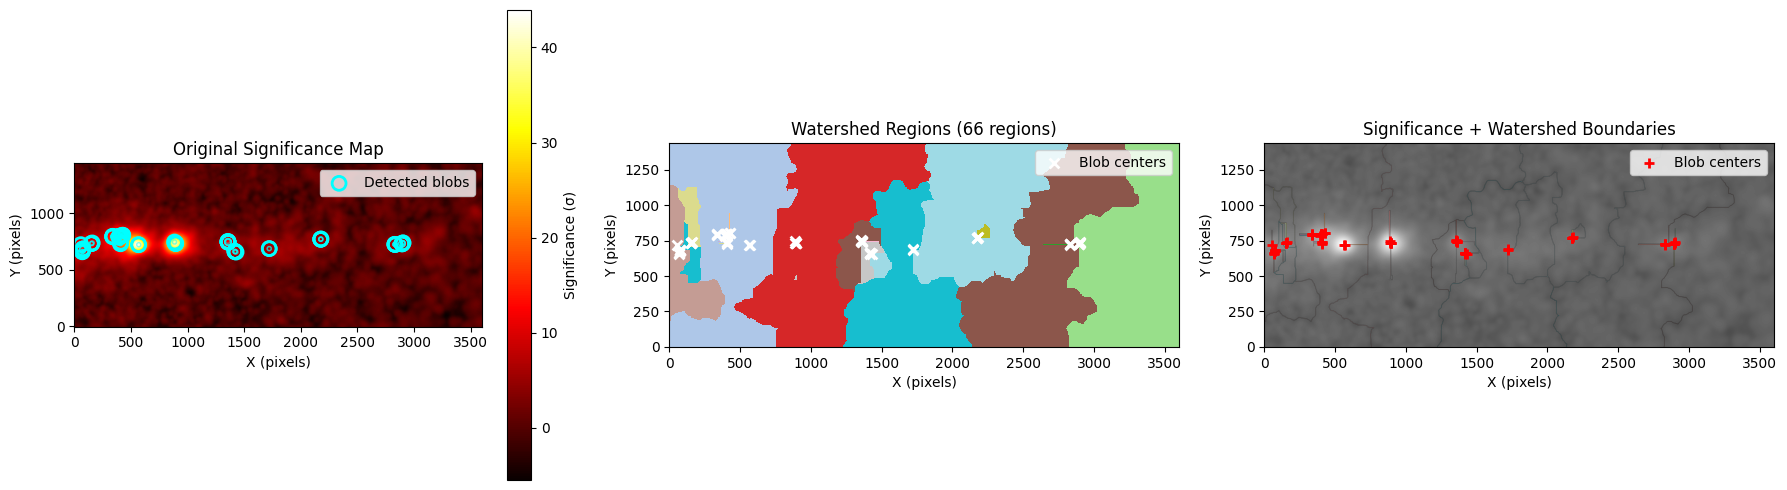

In [9]:
"""
Watershed-based blob merging to prevent source fragmentation in gamma-ray maps.

The watershed algorithm treats the significance map as a topographic surface,
where bright sources are peaks. It assigns each pixel to the nearest local maximum,
effectively grouping fragmented detections that belong to the same source.
"""

import numpy as np
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy.ndimage import label as ndi_label


def watershed_merge_blobs(blobs, coords, radii, significance_map, pixel_size,
                         significances=None, min_distance=None, 
                         watershed_line=False, compactness=0):
    """
    Merge fragmented blobs using watershed segmentation.
    
    The watershed algorithm groups nearby blob detections by finding catchment
    basins in the inverted significance map. Blobs that fall within the same
    watershed region are merged into a single source.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values (in degrees)
    significance_map : 2D array
        Original significance map (unnormalized)
    pixel_size : float
        Pixel size in degrees
    significances : list of float, optional
        Peak significance values for each blob
    min_distance : float, optional
        Minimum distance between watershed seeds in pixels.
        Default: median blob radius
    watershed_line : bool
        If True, create separation lines between regions (default: False)
    compactness : float
        Compactness parameter for watershed (0 = standard, >0 = more compact)
    
    Returns:
    --------
    merged_blobs, merged_coords, merged_radii, [merged_sigs]
    """
    
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    if len(blobs) == 1:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append(significances)
        return tuple(return_vals)
    
    print(f"\nWatershed merging: {len(blobs)} initial blobs")
    
    # Set default min_distance based on blob sizes
    if min_distance is None:
        radii_pixels = blobs[:, 2]
        min_distance = int(np.median(radii_pixels))
        print(f"Using min_distance: {min_distance} pixels ({min_distance * pixel_size:.3f}°)")
    
    # Create binary mask of detected regions
    # Expand each blob by its radius to create regions
    mask = np.zeros_like(significance_map, dtype=bool)
    for blob in blobs:
        y, x, r = blob
        yy, xx = np.ogrid[:significance_map.shape[0], :significance_map.shape[1]]
        distance = np.sqrt((yy - y)**2 + (xx - x)**2)
        mask = mask | (distance <= r * 1.5)  # Slightly expand regions
    
    # Create markers from blob positions
    # Each blob gets a unique label
    markers = np.zeros_like(significance_map, dtype=int)
    for i, blob in enumerate(blobs):
        y, x, r = blob
        # Mark the exact center position
        markers[int(y), int(x)] = i + 1
    
    # Apply watershed on the INVERTED significance map
    # (watershed finds minima, but we want maxima)
    inverted_map = -significance_map
    
    # Only watershed within the masked region
    inverted_map_masked = inverted_map.copy()
    inverted_map_masked[~mask] = inverted_map.max()  # Set background to high value
    
    # Perform watershed
    labels = watershed(inverted_map_masked, markers, mask=mask, 
                      watershed_line=watershed_line, compactness=compactness)
    
    print(f"Watershed created {labels.max()} regions")
    
    # Group blobs that fall in the same watershed region
    blob_to_region = {}
    for i, blob in enumerate(blobs):
        y, x, r = blob
        region_label = labels[int(y), int(x)]
        
        if region_label not in blob_to_region:
            blob_to_region[region_label] = []
        blob_to_region[region_label].append(i)
    
    # Merge blobs within each region
    merged_blobs = []
    merged_coords = []
    merged_radii = []
    merged_sigs = [] if significances is not None else None
    
    fragments_merged = 0
    
    for region_label, blob_indices in blob_to_region.items():
        if region_label == 0:  # Skip background
            continue
        
        if len(blob_indices) == 1:
            # Single blob in region - keep as is
            idx = blob_indices[0]
            merged_blobs.append(blobs[idx])
            merged_coords.append(coords[idx])
            merged_radii.append(radii[idx])
            if significances is not None:
                merged_sigs.append(significances[idx])
        else:
            # Multiple blobs in same region - merge them
            fragments_merged += len(blob_indices) - 1
            
            region_blobs = blobs[blob_indices]
            region_radii = [radii[i] for i in blob_indices]
            region_coords = [coords[i] for i in blob_indices]
            
            if significances is not None:
                region_sigs = [significances[i] for i in blob_indices]
                
                # Find the most significant blob (this becomes the merged position)
                max_sig_local_idx = np.argmax(region_sigs)
                max_sig_idx = blob_indices[max_sig_local_idx]
                
                # Use position of most significant blob
                merged_y, merged_x = blobs[max_sig_idx, 0], blobs[max_sig_idx, 1]
                merged_coord = coords[max_sig_idx]
                merged_sig = region_sigs[max_sig_local_idx]
                
                # Radius: use the largest detected radius in this region
                merged_r = max(region_radii)
            else:
                # Without significances, use the largest blob
                max_r_local_idx = np.argmax(region_radii)
                max_r_idx = blob_indices[max_r_local_idx]
                
                merged_y, merged_x = blobs[max_r_idx, 0], blobs[max_r_idx, 1]
                merged_coord = coords[max_r_idx]
                merged_r = region_radii[max_r_local_idx]
            
            merged_blobs.append([merged_y, merged_x, merged_r])
            merged_coords.append(merged_coord)
            merged_radii.append(merged_r)
            if significances is not None:
                merged_sigs.append(merged_sig)
    
    merged_blobs = np.array(merged_blobs)
    
    print(f"Watershed merging complete:")
    print(f"  {len(blobs)} blobs → {len(merged_blobs)} sources")
    print(f"  {fragments_merged} fragments merged")
    print(f"  {100 * fragments_merged / len(blobs):.1f}% reduction")
    
    if significances is not None:
        return merged_blobs, merged_coords, merged_radii, merged_sigs
    return merged_blobs, merged_coords, merged_radii


def advanced_watershed_merge(blobs, coords, radii, significance_map, pixel_size,
                            significances=None, use_local_maxima=True,
                            sigma_smooth=2.0, min_significance_fraction=0.3):
    """
    Advanced watershed merging using automatically detected local maxima.
    
    Instead of using blob positions as seeds, this finds local maxima in the
    smoothed significance map and uses those as watershed seeds. This is more
    robust for complex, extended sources.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Initial blob detections
    coords : list of SkyCoord objects
        Sky coordinates
    radii : list of float
        Blob radii
    significance_map : 2D array
        Original significance map
    pixel_size : float
        Pixel size in degrees
    significances : list of float, optional
        Peak significances
    use_local_maxima : bool
        If True, use automatically detected local maxima as seeds
        If False, use blob positions as seeds
    sigma_smooth : float
        Gaussian smoothing sigma before finding local maxima
    min_significance_fraction : float
        Minimum significance as fraction of global max for local maxima
    
    Returns:
    --------
    merged_blobs, merged_coords, merged_radii, [merged_sigs]
    """
    
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    print(f"\nAdvanced watershed merging: {len(blobs)} initial blobs")
    
    # Smooth the significance map
    smoothed_map = ndi.gaussian_filter(significance_map, sigma=sigma_smooth)
    
    if use_local_maxima:
        # Find local maxima automatically
        min_distance_pixels = int(0.2 / pixel_size)  # 0.2 degree minimum separation
        threshold_abs = min_significance_fraction * smoothed_map.max()
        
        print(f"Finding local maxima with min_distance={min_distance_pixels} pixels")
        print(f"Threshold: {threshold_abs:.2f} sigma")
        
        # Find peaks
        local_max_coords = peak_local_max(smoothed_map, 
                                         min_distance=min_distance_pixels,
                                         threshold_abs=threshold_abs,
                                         exclude_border=20)
        
        print(f"Found {len(local_max_coords)} local maxima")
        
        # Create markers from local maxima
        markers = np.zeros_like(significance_map, dtype=int)
        for i, (y, x) in enumerate(local_max_coords):
            markers[y, x] = i + 1
        
        # Create mask: regions above some threshold
        mask = smoothed_map > (0.1 * smoothed_map.max())
        
    else:
        # Use blob positions as markers (original approach)
        markers = np.zeros_like(significance_map, dtype=int)
        for i, blob in enumerate(blobs):
            y, x, r = blob
            markers[int(y), int(x)] = i + 1
        
        # Mask based on blob regions
        mask = np.zeros_like(significance_map, dtype=bool)
        for blob in blobs:
            y, x, r = blob
            yy, xx = np.ogrid[:significance_map.shape[0], :significance_map.shape[1]]
            distance = np.sqrt((yy - y)**2 + (xx - x)**2)
            mask = mask | (distance <= r * 1.5)
        
        local_max_coords = None
    
    # Perform watershed on inverted, smoothed map
    inverted_map = -smoothed_map
    labels = watershed(inverted_map, markers, mask=mask, compactness=0.001)
    
    print(f"Watershed segmentation created {labels.max()} regions")
    
    # Assign each blob to its watershed region
    blob_to_region = {}
    for i, blob in enumerate(blobs):
        y, x, r = blob
        region_label = labels[int(y), int(x)]
        
        if region_label not in blob_to_region:
            blob_to_region[region_label] = []
        blob_to_region[region_label].append(i)
    
    # Merge blobs in same region
    merged_blobs = []
    merged_coords = []
    merged_radii = []
    merged_sigs = [] if significances is not None else None
    
    for region_label, blob_indices in blob_to_region.items():
        if region_label == 0:
            continue
        
        if len(blob_indices) == 1:
            idx = blob_indices[0]
            merged_blobs.append(blobs[idx])
            merged_coords.append(coords[idx])
            merged_radii.append(radii[idx])
            if significances is not None:
                merged_sigs.append(significances[idx])
        else:
            # Merge multiple blobs
            region_blobs = blobs[blob_indices]
            region_radii = [radii[i] for i in blob_indices]
            region_coords = [coords[i] for i in blob_indices]
            
            # Find centroid of the watershed region
            region_mask = (labels == region_label)
            region_values = significance_map * region_mask
            
            # Significance-weighted centroid
            total_sig = region_values.sum()
            if total_sig > 0:
                yy, xx = np.ogrid[:significance_map.shape[0], :significance_map.shape[1]]
                merged_y = (yy * region_values).sum() / total_sig
                merged_x = (xx * region_values).sum() / total_sig
            else:
                # Fallback to mean position
                merged_y = np.mean(region_blobs[:, 0])
                merged_x = np.mean(region_blobs[:, 1])
            
            # Peak significance in region
            merged_sig_value = region_values.max()
            
            # Maximum radius among fragments
            merged_r = max(region_radii)
            
            # Find closest coordinate to merged position
            distances_to_merged = np.sqrt((region_blobs[:, 0] - merged_y)**2 + 
                                         (region_blobs[:, 1] - merged_x)**2)
            closest_idx = blob_indices[np.argmin(distances_to_merged)]
            merged_coord = coords[closest_idx]
            
            merged_blobs.append([merged_y, merged_x, merged_r])
            merged_coords.append(merged_coord)
            merged_radii.append(merged_r)
            if significances is not None:
                merged_sigs.append(merged_sig_value)
    
    merged_blobs = np.array(merged_blobs)
    
    print(f"Advanced watershed complete:")
    print(f"  {len(blobs)} blobs → {len(merged_blobs)} sources")
    print(f"  {len(blobs) - len(merged_blobs)} fragments removed")
    
    if significances is not None:
        return merged_blobs, merged_coords, merged_radii, merged_sigs
    return merged_blobs, merged_coords, merged_radii


def visualize_watershed_segmentation(significance_map, blobs, labels, 
                                     wcs=None, pixel_size=None, save_path=None):
    """
    Visualize the watershed segmentation result.
    
    Parameters:
    -----------
    significance_map : 2D array
        Original significance map
    blobs : array
        Blob detections
    labels : 2D array
        Watershed labels (output from watershed algorithm)
    wcs : WCS object, optional
        For coordinate overlay
    pixel_size : float, optional
        For scale bar
    save_path : str, optional
        Path to save figure
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Original significance map
    im0 = axes[0].imshow(significance_map, cmap='hot', origin='lower')
    axes[0].set_title('Original Significance Map')
    plt.colorbar(im0, ax=axes[0], label='Significance (σ)')
    
    # Blob detections
    axes[0].scatter(blobs[:, 1], blobs[:, 0], s=100, 
                   facecolors='none', edgecolors='cyan', linewidths=2,
                   label='Detected blobs')
    for blob in blobs:
        y, x, r = blob
        circle = plt.Circle((x, y), r, fill=False, color='cyan', linewidth=1, alpha=0.5)
        axes[0].add_patch(circle)
    axes[0].legend()
    
    # Watershed labels
    # Create custom colormap for regions
    n_regions = labels.max()
    colors = plt.cm.tab20(np.linspace(0, 1, n_regions))
    colors = np.vstack([[0, 0, 0, 1], colors])  # Black for background
    cmap_regions = ListedColormap(colors)
    
    im1 = axes[1].imshow(labels, cmap=cmap_regions, origin='lower', interpolation='nearest')
    axes[1].set_title(f'Watershed Regions ({n_regions} regions)')
    axes[1].scatter(blobs[:, 1], blobs[:, 0], s=50, c='white', 
                   marker='x', linewidths=2, label='Blob centers')
    axes[1].legend()
    
    # Overlay: regions on significance map
    axes[2].imshow(significance_map, cmap='gray', origin='lower', alpha=0.7)
    
    # Draw region boundaries
    from skimage.segmentation import find_boundaries
    boundaries = find_boundaries(labels, mode='thick')
    
    # Color boundaries by region
    boundary_overlay = np.zeros((*labels.shape, 4))
    for region_id in range(1, n_regions + 1):
        region_boundary = find_boundaries(labels == region_id, mode='thick')
        color = colors[region_id]
        boundary_overlay[region_boundary] = color
    
    axes[2].imshow(boundary_overlay, origin='lower')
    axes[2].set_title('Significance + Watershed Boundaries')
    axes[2].scatter(blobs[:, 1], blobs[:, 0], s=50, c='red', 
                   marker='+', linewidths=2, label='Blob centers')
    axes[2].legend()
    
    for ax in axes:
        ax.set_xlabel('X (pixels)')
        ax.set_ylabel('Y (pixels)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved watershed visualization to {save_path}")
    
    return fig, axes


# ============================================================================
# INTEGRATION WITH YOUR PIPELINE
# ============================================================================

def integrate_watershed_into_pipeline(norm_image, array, wcs, pixel_size,
                                     blob_filter_intensity, 
                                     radii_range=None,
                                     min_intensity=5,
                                     watershed_method='standard',
                                     visualize=False):
    """
    Complete detection pipeline with watershed-based fragment merging.
    
    Parameters:
    -----------
    watershed_method : str
        'standard' - use blob positions as watershed seeds
        'advanced' - automatically detect local maxima as seeds
    visualize : bool
        Whether to create visualization of watershed segmentation
    """
    
    if radii_range is None:
        radii_range = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    
    from skimage.filters import difference_of_gaussians
    import scipy.ndimage as ndi
    from skimage.feature import blob_dog
    from astropy.stats import sigma_clip
    
    def estimate_background_sigma(image, sigma=3, maxiters=5):
        clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
        return np.std(clipped.data[~clipped.mask])
    
    # Storage
    all_blobs = []
    all_coords = []
    all_radii = []
    all_sigs = []
    
    base_threshold = 0.01
    
    print("="*70)
    print("MULTI-SCALE BLOB DETECTION WITH WATERSHED MERGING")
    print("="*70)
    
    # Multi-scale detection
    for smear_radius in radii_range:
        print(f"\n--- Radius: {smear_radius:.2f}° ---")
        
        dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
        dog_smooth = ndi.gaussian_filter(dog_image, sigma=1.0)
        sigma_resid = estimate_background_sigma(dog_image)
        dog_final = np.where(dog_smooth > 2 * sigma_resid, dog_smooth, 0)
        
        blobs = blob_dog(dog_final,
                        min_sigma=0.1/pixel_size,
                        max_sigma=smear_radius/pixel_size,
                        threshold=base_threshold,
                        exclude_border=50,
                        overlap=0.5)
        
        print(f"Detected: {len(blobs)} blobs")
        
        if len(blobs) > 0:
            filtered_blobs, filtered_coords, filtered_radii = \
                blob_filter_intensity(blobs, array, min_intensity, wcs, pixel_size)
            
            if len(filtered_blobs) > 0:
                sigs = [array[int(b[0]), int(b[1])] for b in filtered_blobs]
                all_blobs.append(filtered_blobs)
                all_coords.append(filtered_coords)
                all_radii.append(filtered_radii)
                all_sigs.append(sigs)
                print(f"After filtering: {len(filtered_blobs)} blobs")
    
    # Combine detections
    if len(all_blobs) == 0:
        print("\nNo blobs detected!")
        return {
            'ps_blobs': np.array([]).reshape(0, 3),
            'ps_coords': [],
            'ps_radii': [],
            'ps_significances': []
        }
    
    combined_blobs = np.vstack(all_blobs)
    combined_coords = [c for sublist in all_coords for c in sublist]
    combined_radii = [r for sublist in all_radii for r in sublist]
    combined_sigs = [s for sublist in all_sigs for s in sublist]
    
    print(f"\n{'='*70}")
    print(f"TOTAL DETECTIONS: {len(combined_blobs)}")
    print(f"{'='*70}")
    
    # WATERSHED MERGING
    if watershed_method == 'advanced':
        merged_result = advanced_watershed_merge(
            combined_blobs, combined_coords, combined_radii, array, pixel_size,
            combined_sigs, use_local_maxima=True, sigma_smooth=2.0
        )
    else:
        merged_result = watershed_merge_blobs(
            combined_blobs, combined_coords, combined_radii, array, pixel_size,
            combined_sigs, min_distance=None
        )
    
    merged_blobs, merged_coords, merged_radii, merged_sigs = merged_result
    
    # Visualization
    if visualize and len(merged_blobs) > 0:
        # Re-run watershed to get labels for visualization
        markers = np.zeros_like(array, dtype=int)
        for i, blob in enumerate(merged_blobs):
            y, x, r = blob
            markers[int(y), int(x)] = i + 1
        
        mask = np.ones_like(array, dtype=bool)
        inverted = -ndi.gaussian_filter(array, sigma=2.0)
        labels = watershed(inverted, markers, mask=mask)
        
        fig, axes = visualize_watershed_segmentation(
            array, merged_blobs, labels, wcs, pixel_size
        )
    
    # Final overlap removal (optional - for any remaining duplicates)
    print(f"\n{'='*70}")
    print("FINAL OVERLAP REMOVAL")
    print(f"{'='*70}")
    
    from enhanced_blob_detection import remove_overlapping_blobs
    final_blobs, final_coords, final_radii, final_sigs = \
        remove_overlapping_blobs(merged_blobs, merged_coords, merged_radii, 
                                merged_sigs, overlap_threshold=0.5,
                                separation_factor=1.2)
    
    print(f"\n{'='*70}")
    print(f"FINAL RESULTS: {len(final_blobs)} unique sources")
    print(f"Fragmentation reduction: {len(combined_blobs)} → {len(final_blobs)}")
    print(f"  ({100*(len(combined_blobs) - len(final_blobs))/len(combined_blobs):.1f}% reduction)")
    print(f"{'='*70}")
    
    return {
        'ps_blobs': final_blobs,
        'ps_coords': final_coords,
        'ps_radii': final_radii,
        'ps_significances': final_sigs
    }


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

# Standard watershed (uses blob positions as seeds)
results = integrate_watershed_into_pipeline(
    norm_image, array, wcs, pixel_size,
    blob_filter_intensity,
    radii_range=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    min_intensity=5,
    watershed_method='standard',
    visualize=True
)

# Advanced watershed (automatically finds local maxima)
results = integrate_watershed_into_pipeline(
    norm_image, array, wcs, pixel_size,
    blob_filter_intensity,
    radii_range=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    min_intensity=5,
    watershed_method='advanced',
    visualize=True
)

final_ps_blobs = results['ps_blobs']
final_ps_coords = results['ps_coords']
final_ps_radii = results['ps_radii']
final_ps_sigs = results['ps_significances']

# Plot final results
if len(final_ps_blobs) > 0:
    blobs_dict = {'psblobs': final_ps_blobs}
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G',
                        blobs=blobs_dict,
                        title='Watershed-Merged Detections',
                        cmap='ult', labels=['4hawc'])

MULTI-SCALE BLOB DETECTION WITH WATERSHED MERGING

--- Radius: 0.15° ---
Detected: 18 blobs
Blob Intensity 42.862495656425715, Coords (273.37467699394904 deg, -17.79450788758014 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 38.96417413188284, Coords (272.3597045973192 deg, -19.269554410481373 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 11.909495309549257, Coords (270.9668907063199 deg, -21.53806404696872 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 22.201837690792033, Coords (273.3419778125869 deg, -16.878083079717754 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 8.316723464430257, Coords (266.2200555228313 deg, -28.987873738612404 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 12.941891011833006, Coords (275.0720010762001 deg, -15.519785683550408 deg), Radius 18.0, Pixel Radius 0.1
Blob Intensity 17.07275871656471, Coords (273.6348671571542 deg, -16.46759821552675 deg), Radius 18.0, Pixel Radius 0.1
After filtering: 7 blobs

--- Radius: 0.20° ---
Detected: 2

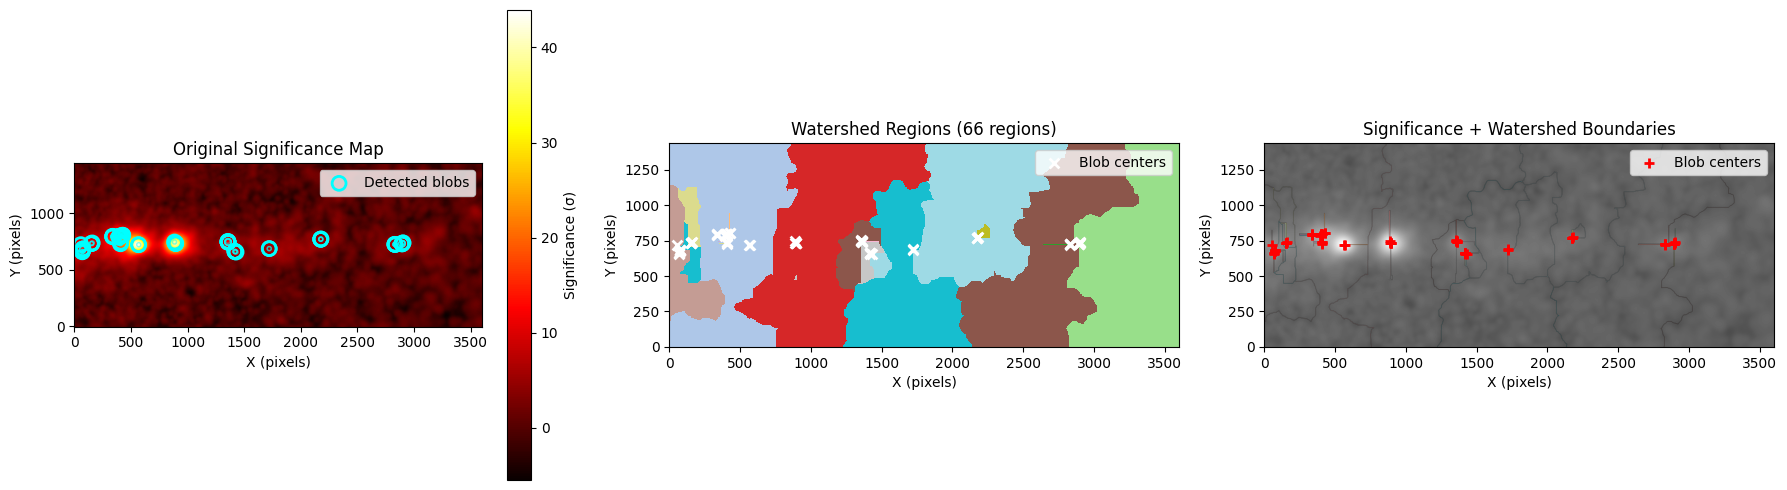

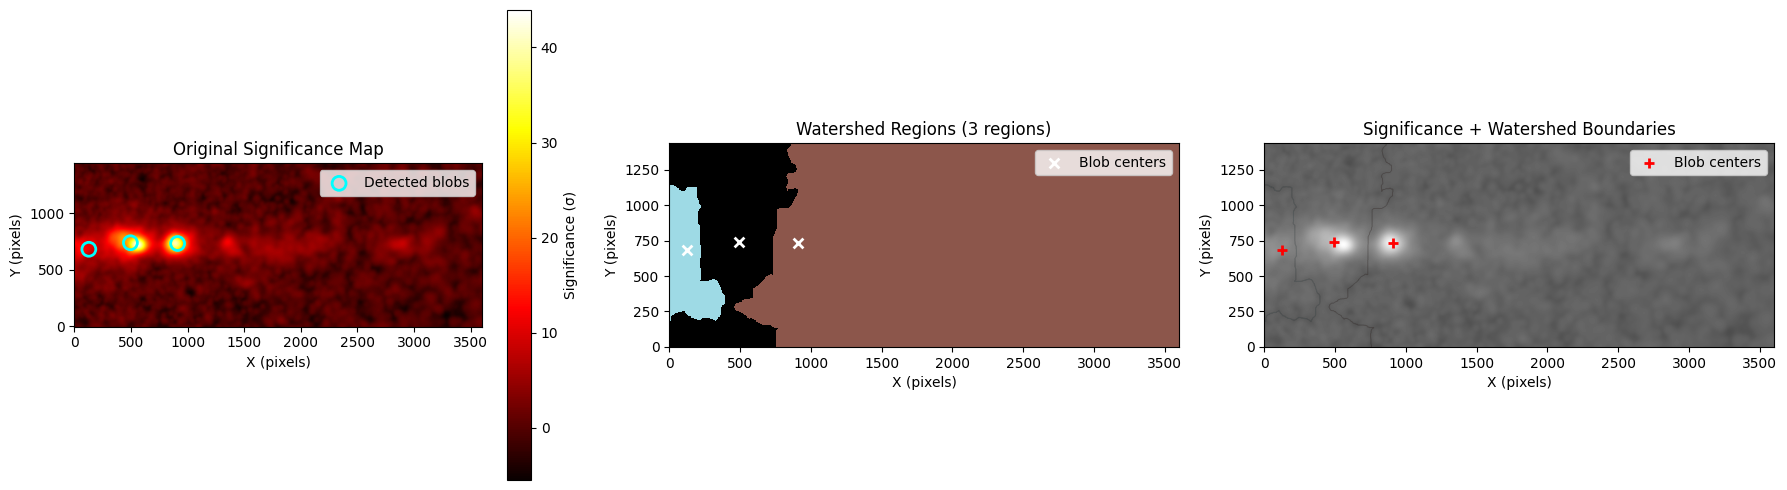

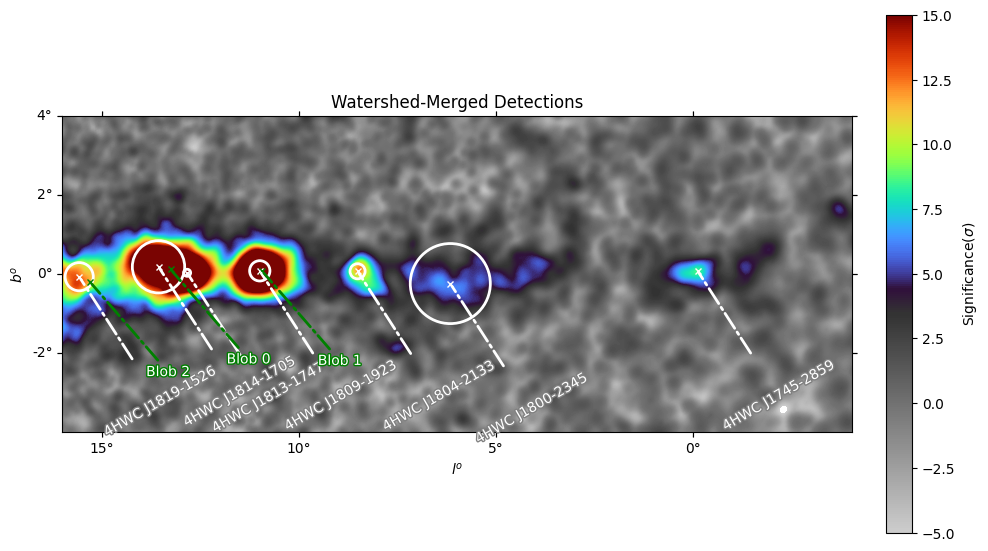

In [11]:
"""
Watershed-based blob merging to prevent source fragmentation in gamma-ray maps.

The watershed algorithm treats the significance map as a topographic surface,
where bright sources are peaks. It assigns each pixel to the nearest local maximum,
effectively grouping fragmented detections that belong to the same source.
"""

import numpy as np
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy.ndimage import label as ndi_label


def watershed_merge_blobs(blobs, coords, radii, significance_map, pixel_size,
                         significances=None, min_distance=None, 
                         watershed_line=False, compactness=0):
    """
    Merge fragmented blobs using watershed segmentation.
    
    The watershed algorithm groups nearby blob detections by finding catchment
    basins in the inverted significance map. Blobs that fall within the same
    watershed region are merged into a single source.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values (in degrees)
    significance_map : 2D array
        Original significance map (unnormalized)
    pixel_size : float
        Pixel size in degrees
    significances : list of float, optional
        Peak significance values for each blob
    min_distance : float, optional
        Minimum distance between watershed seeds in pixels.
        Default: median blob radius
    watershed_line : bool
        If True, create separation lines between regions (default: False)
    compactness : float
        Compactness parameter for watershed (0 = standard, >0 = more compact)
    
    Returns:
    --------
    merged_blobs, merged_coords, merged_radii, [merged_sigs]
    """
    
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    if len(blobs) == 1:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append(significances)
        return tuple(return_vals)
    
    print(f"\nWatershed merging: {len(blobs)} initial blobs")
    
    # Set default min_distance based on blob sizes
    if min_distance is None:
        radii_pixels = blobs[:, 2]
        min_distance = int(np.median(radii_pixels))
        print(f"Using min_distance: {min_distance} pixels ({min_distance * pixel_size:.3f}°)")
    
    # Create binary mask of detected regions
    # Expand each blob by its radius to create regions
    mask = np.zeros_like(significance_map, dtype=bool)
    for blob in blobs:
        y, x, r = blob
        yy, xx = np.ogrid[:significance_map.shape[0], :significance_map.shape[1]]
        distance = np.sqrt((yy - y)**2 + (xx - x)**2)
        mask = mask | (distance <= r * 1.5)  # Slightly expand regions
    
    # Create markers from blob positions
    # Each blob gets a unique label
    markers = np.zeros_like(significance_map, dtype=int)
    for i, blob in enumerate(blobs):
        y, x, r = blob
        # Mark the exact center position
        markers[int(y), int(x)] = i + 1
    
    # Apply watershed on the INVERTED significance map
    # (watershed finds minima, but we want maxima)
    inverted_map = -significance_map
    
    # Only watershed within the masked region
    inverted_map_masked = inverted_map.copy()
    inverted_map_masked[~mask] = inverted_map.max()  # Set background to high value
    
    # Perform watershed
    labels = watershed(inverted_map_masked, markers, mask=mask, 
                      watershed_line=watershed_line, compactness=compactness)
    
    print(f"Watershed created {labels.max()} regions")
    
    # Group blobs that fall in the same watershed region
    blob_to_region = {}
    for i, blob in enumerate(blobs):
        y, x, r = blob
        region_label = labels[int(y), int(x)]
        
        if region_label not in blob_to_region:
            blob_to_region[region_label] = []
        blob_to_region[region_label].append(i)
    
    # Merge blobs within each region
    merged_blobs = []
    merged_coords = []
    merged_radii = []
    merged_sigs = [] if significances is not None else None
    
    fragments_merged = 0
    
    for region_label, blob_indices in blob_to_region.items():
        if region_label == 0:  # Skip background
            continue
        
        if len(blob_indices) == 1:
            # Single blob in region - keep as is
            idx = blob_indices[0]
            merged_blobs.append(blobs[idx])
            merged_coords.append(coords[idx])
            merged_radii.append(radii[idx])
            if significances is not None:
                merged_sigs.append(significances[idx])
        else:
            # Multiple blobs in same region - merge them
            fragments_merged += len(blob_indices) - 1
            
            region_blobs = blobs[blob_indices]
            region_radii = [radii[i] for i in blob_indices]
            region_coords = [coords[i] for i in blob_indices]
            
            if significances is not None:
                region_sigs = [significances[i] for i in blob_indices]
                
                # Find the most significant blob (this becomes the merged position)
                max_sig_local_idx = np.argmax(region_sigs)
                max_sig_idx = blob_indices[max_sig_local_idx]
                
                # Use position of most significant blob
                merged_y, merged_x = blobs[max_sig_idx, 0], blobs[max_sig_idx, 1]
                merged_coord = coords[max_sig_idx]
                merged_sig = region_sigs[max_sig_local_idx]
                
                # Radius: use the largest detected radius in this region
                merged_r = max(region_radii)
            else:
                # Without significances, use the largest blob
                max_r_local_idx = np.argmax(region_radii)
                max_r_idx = blob_indices[max_r_local_idx]
                
                merged_y, merged_x = blobs[max_r_idx, 0], blobs[max_r_idx, 1]
                merged_coord = coords[max_r_idx]
                merged_r = region_radii[max_r_local_idx]
            
            merged_blobs.append([merged_y, merged_x, merged_r])
            merged_coords.append(merged_coord)
            merged_radii.append(merged_r)
            if significances is not None:
                merged_sigs.append(merged_sig)
    
    merged_blobs = np.array(merged_blobs)
    
    print(f"Watershed merging complete:")
    print(f"  {len(blobs)} blobs → {len(merged_blobs)} sources")
    print(f"  {fragments_merged} fragments merged")
    print(f"  {100 * fragments_merged / len(blobs):.1f}% reduction")
    
    if significances is not None:
        return merged_blobs, merged_coords, merged_radii, merged_sigs
    return merged_blobs, merged_coords, merged_radii


def remove_overlapping_blobs(blobs, coords, radii, significances=None, 
                            overlap_threshold=0.5, separation_factor=1.5):
    """
    Remove overlapping blobs, keeping the most significant one.
    (Self-contained version - no external imports needed)
    """
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    # Sort by significance if available, otherwise by radius (descending)
    if significances is not None:
        sorted_indices = np.argsort(significances)[::-1]
        sorted_sigs = [significances[i] for i in sorted_indices]
    else:
        sorted_indices = np.argsort(blobs[:, 2])[::-1]
        sorted_sigs = None
    
    sorted_blobs = blobs[sorted_indices]
    sorted_coords = [coords[i] for i in sorted_indices]
    sorted_radii = [radii[i] for i in sorted_indices]
    
    keep_mask = np.ones(len(sorted_blobs), dtype=bool)
    
    for i in range(len(sorted_blobs)):
        if not keep_mask[i]:
            continue
        
        # Calculate distance to all other blobs
        distances = np.sqrt((sorted_blobs[i, 0] - sorted_blobs[:, 0])**2 + 
                          (sorted_blobs[i, 1] - sorted_blobs[:, 1])**2)
        
        # Check for overlap (geometric overlap)
        radii_sum = sorted_blobs[i, 2] + sorted_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        
        # Also check proximity (catches same source at different scales)
        max_radius = np.maximum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        is_nearby = distances < separation_factor * max_radius
        
        # Mark as duplicate if either overlapping OR nearby
        is_duplicate = (overlap > overlap_threshold) | is_nearby
        
        keep_mask[is_duplicate] = False
        keep_mask[i] = True  # Always keep current blob
    
    # Filter all arrays/lists
    filtered_blobs = sorted_blobs[keep_mask]
    filtered_coords = [coord for i, coord in enumerate(sorted_coords) if keep_mask[i]]
    filtered_radii = [radius for i, radius in enumerate(sorted_radii) if keep_mask[i]]
    
    if sorted_sigs is not None:
        filtered_sigs = [sig for i, sig in enumerate(sorted_sigs) if keep_mask[i]]
        return filtered_blobs, filtered_coords, filtered_radii, filtered_sigs
    
    return filtered_blobs, filtered_coords, filtered_radii


def advanced_watershed_merge(blobs, coords, radii, significance_map, pixel_size,
                            significances=None, use_local_maxima=True,
                            sigma_smooth=2.0, min_significance_fraction=0.3):
    """
    Advanced watershed merging using automatically detected local maxima.
    
    Instead of using blob positions as seeds, this finds local maxima in the
    smoothed significance map and uses those as watershed seeds. This is more
    robust for complex, extended sources.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Initial blob detections
    coords : list of SkyCoord objects
        Sky coordinates
    radii : list of float
        Blob radii
    significance_map : 2D array
        Original significance map
    pixel_size : float
        Pixel size in degrees
    significances : list of float, optional
        Peak significances
    use_local_maxima : bool
        If True, use automatically detected local maxima as seeds
        If False, use blob positions as seeds
    sigma_smooth : float
        Gaussian smoothing sigma before finding local maxima
    min_significance_fraction : float
        Minimum significance as fraction of global max for local maxima
    
    Returns:
    --------
    merged_blobs, merged_coords, merged_radii, [merged_sigs]
    """
    
    if len(blobs) == 0:
        return_vals = [blobs, coords, radii]
        if significances is not None:
            return_vals.append([])
        return tuple(return_vals)
    
    print(f"\nAdvanced watershed merging: {len(blobs)} initial blobs")
    
    # Smooth the significance map
    smoothed_map = ndi.gaussian_filter(significance_map, sigma=sigma_smooth)
    
    if use_local_maxima:
        # Find local maxima automatically
        min_distance_pixels = int(0.2 / pixel_size)  # 0.2 degree minimum separation
        threshold_abs = min_significance_fraction * smoothed_map.max()
        
        print(f"Finding local maxima with min_distance={min_distance_pixels} pixels")
        print(f"Threshold: {threshold_abs:.2f} sigma")
        
        # Find peaks
        local_max_coords = peak_local_max(smoothed_map, 
                                         min_distance=min_distance_pixels,
                                         threshold_abs=threshold_abs,
                                         exclude_border=20)
        
        print(f"Found {len(local_max_coords)} local maxima")
        
        # Create markers from local maxima
        markers = np.zeros_like(significance_map, dtype=int)
        for i, (y, x) in enumerate(local_max_coords):
            markers[y, x] = i + 1
        
        # Create mask: regions above some threshold
        mask = smoothed_map > (0.1 * smoothed_map.max())
        
    else:
        # Use blob positions as markers (original approach)
        markers = np.zeros_like(significance_map, dtype=int)
        for i, blob in enumerate(blobs):
            y, x, r = blob
            markers[int(y), int(x)] = i + 1
        
        # Mask based on blob regions
        mask = np.zeros_like(significance_map, dtype=bool)
        for blob in blobs:
            y, x, r = blob
            yy, xx = np.ogrid[:significance_map.shape[0], :significance_map.shape[1]]
            distance = np.sqrt((yy - y)**2 + (xx - x)**2)
            mask = mask | (distance <= r * 1.5)
        
        local_max_coords = None
    
    # Perform watershed on inverted, smoothed map
    inverted_map = -smoothed_map
    labels = watershed(inverted_map, markers, mask=mask, compactness=0.001)
    
    print(f"Watershed segmentation created {labels.max()} regions")
    
    # Assign each blob to its watershed region
    blob_to_region = {}
    for i, blob in enumerate(blobs):
        y, x, r = blob
        region_label = labels[int(y), int(x)]
        
        if region_label not in blob_to_region:
            blob_to_region[region_label] = []
        blob_to_region[region_label].append(i)
    
    # Merge blobs in same region
    merged_blobs = []
    merged_coords = []
    merged_radii = []
    merged_sigs = [] if significances is not None else None
    
    for region_label, blob_indices in blob_to_region.items():
        if region_label == 0:
            continue
        
        if len(blob_indices) == 1:
            idx = blob_indices[0]
            merged_blobs.append(blobs[idx])
            merged_coords.append(coords[idx])
            merged_radii.append(radii[idx])
            if significances is not None:
                merged_sigs.append(significances[idx])
        else:
            # Merge multiple blobs
            region_blobs = blobs[blob_indices]
            region_radii = [radii[i] for i in blob_indices]
            region_coords = [coords[i] for i in blob_indices]
            
            # Find centroid of the watershed region
            region_mask = (labels == region_label)
            region_values = significance_map * region_mask
            
            # Significance-weighted centroid
            total_sig = region_values.sum()
            if total_sig > 0:
                yy, xx = np.ogrid[:significance_map.shape[0], :significance_map.shape[1]]
                merged_y = (yy * region_values).sum() / total_sig
                merged_x = (xx * region_values).sum() / total_sig
            else:
                # Fallback to mean position
                merged_y = np.mean(region_blobs[:, 0])
                merged_x = np.mean(region_blobs[:, 1])
            
            # Peak significance in region
            merged_sig_value = region_values.max()
            
            # Maximum radius among fragments
            merged_r = max(region_radii)
            
            # Find closest coordinate to merged position
            distances_to_merged = np.sqrt((region_blobs[:, 0] - merged_y)**2 + 
                                         (region_blobs[:, 1] - merged_x)**2)
            closest_idx = blob_indices[np.argmin(distances_to_merged)]
            merged_coord = coords[closest_idx]
            
            merged_blobs.append([merged_y, merged_x, merged_r])
            merged_coords.append(merged_coord)
            merged_radii.append(merged_r)
            if significances is not None:
                merged_sigs.append(merged_sig_value)
    
    merged_blobs = np.array(merged_blobs)
    
    print(f"Advanced watershed complete:")
    print(f"  {len(blobs)} blobs → {len(merged_blobs)} sources")
    print(f"  {len(blobs) - len(merged_blobs)} fragments removed")
    
    if significances is not None:
        return merged_blobs, merged_coords, merged_radii, merged_sigs
    return merged_blobs, merged_coords, merged_radii


def visualize_watershed_segmentation(significance_map, blobs, labels, 
                                     wcs=None, pixel_size=None, save_path=None):
    """
    Visualize the watershed segmentation result.
    
    Parameters:
    -----------
    significance_map : 2D array
        Original significance map
    blobs : array
        Blob detections
    labels : 2D array
        Watershed labels (output from watershed algorithm)
    wcs : WCS object, optional
        For coordinate overlay
    pixel_size : float, optional
        For scale bar
    save_path : str, optional
        Path to save figure
    """
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Original significance map
    im0 = axes[0].imshow(significance_map, cmap='hot', origin='lower')
    axes[0].set_title('Original Significance Map')
    plt.colorbar(im0, ax=axes[0], label='Significance (σ)')
    
    # Blob detections
    axes[0].scatter(blobs[:, 1], blobs[:, 0], s=100, 
                   facecolors='none', edgecolors='cyan', linewidths=2,
                   label='Detected blobs')
    for blob in blobs:
        y, x, r = blob
        circle = plt.Circle((x, y), r, fill=False, color='cyan', linewidth=1, alpha=0.5)
        axes[0].add_patch(circle)
    axes[0].legend()
    
    # Watershed labels
    # Create custom colormap for regions
    n_regions = labels.max()
    colors = plt.cm.tab20(np.linspace(0, 1, n_regions))
    colors = np.vstack([[0, 0, 0, 1], colors])  # Black for background
    cmap_regions = ListedColormap(colors)
    
    im1 = axes[1].imshow(labels, cmap=cmap_regions, origin='lower', interpolation='nearest')
    axes[1].set_title(f'Watershed Regions ({n_regions} regions)')
    axes[1].scatter(blobs[:, 1], blobs[:, 0], s=50, c='white', 
                   marker='x', linewidths=2, label='Blob centers')
    axes[1].legend()
    
    # Overlay: regions on significance map
    axes[2].imshow(significance_map, cmap='gray', origin='lower', alpha=0.7)
    
    # Draw region boundaries
    from skimage.segmentation import find_boundaries
    boundaries = find_boundaries(labels, mode='thick')
    
    # Color boundaries by region
    boundary_overlay = np.zeros((*labels.shape, 4))
    for region_id in range(1, n_regions + 1):
        region_boundary = find_boundaries(labels == region_id, mode='thick')
        color = colors[region_id]
        boundary_overlay[region_boundary] = color
    
    axes[2].imshow(boundary_overlay, origin='lower')
    axes[2].set_title('Significance + Watershed Boundaries')
    axes[2].scatter(blobs[:, 1], blobs[:, 0], s=50, c='red', 
                   marker='+', linewidths=2, label='Blob centers')
    axes[2].legend()
    
    for ax in axes:
        ax.set_xlabel('X (pixels)')
        ax.set_ylabel('Y (pixels)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved watershed visualization to {save_path}")
    
    return fig, axes


# ============================================================================
# INTEGRATION WITH YOUR PIPELINE
# ============================================================================

def integrate_watershed_into_pipeline(norm_image, array, wcs, pixel_size,
                                     blob_filter_intensity, 
                                     radii_range=None,
                                     min_intensity=5,
                                     watershed_method='standard',
                                     visualize=False):
    """
    Complete detection pipeline with watershed-based fragment merging.
    
    Parameters:
    -----------
    watershed_method : str
        'standard' - use blob positions as watershed seeds
        'advanced' - automatically detect local maxima as seeds
    visualize : bool
        Whether to create visualization of watershed segmentation
    """
    
    if radii_range is None:
        radii_range = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
    
    from skimage.filters import difference_of_gaussians
    import scipy.ndimage as ndi
    from skimage.feature import blob_dog
    from astropy.stats import sigma_clip
    
    def estimate_background_sigma(image, sigma=3, maxiters=5):
        clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
        return np.std(clipped.data[~clipped.mask])
    
    # Storage
    all_blobs = []
    all_coords = []
    all_radii = []
    all_sigs = []
    
    base_threshold = 0.01
    
    print("="*70)
    print("MULTI-SCALE BLOB DETECTION WITH WATERSHED MERGING")
    print("="*70)
    
    # Multi-scale detection
    for smear_radius in radii_range:
        print(f"\n--- Radius: {smear_radius:.2f}° ---")
        
        dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
        dog_smooth = ndi.gaussian_filter(dog_image, sigma=1.0)
        sigma_resid = estimate_background_sigma(dog_image)
        dog_final = np.where(dog_smooth > 2 * sigma_resid, dog_smooth, 0)
        
        blobs = blob_dog(dog_final,
                        min_sigma=0.1/pixel_size,
                        max_sigma=smear_radius/pixel_size,
                        threshold=base_threshold,
                        exclude_border=50,
                        overlap=0.5)
        
        print(f"Detected: {len(blobs)} blobs")
        
        if len(blobs) > 0:
            filtered_blobs, filtered_coords, filtered_radii = \
                blob_filter_intensity(blobs, array, min_intensity, wcs, pixel_size)
            
            if len(filtered_blobs) > 0:
                sigs = [array[int(b[0]), int(b[1])] for b in filtered_blobs]
                all_blobs.append(filtered_blobs)
                all_coords.append(filtered_coords)
                all_radii.append(filtered_radii)
                all_sigs.append(sigs)
                print(f"After filtering: {len(filtered_blobs)} blobs")
    
    # Combine detections
    if len(all_blobs) == 0:
        print("\nNo blobs detected!")
        return {
            'ps_blobs': np.array([]).reshape(0, 3),
            'ps_coords': [],
            'ps_radii': [],
            'ps_significances': []
        }
    
    combined_blobs = np.vstack(all_blobs)
    combined_coords = [c for sublist in all_coords for c in sublist]
    combined_radii = [r for sublist in all_radii for r in sublist]
    combined_sigs = [s for sublist in all_sigs for s in sublist]
    
    print(f"\n{'='*70}")
    print(f"TOTAL DETECTIONS: {len(combined_blobs)}")
    print(f"{'='*70}")
    
    # WATERSHED MERGING
    if watershed_method == 'advanced':
        merged_result = advanced_watershed_merge(
            combined_blobs, combined_coords, combined_radii, array, pixel_size,
            combined_sigs, use_local_maxima=True, sigma_smooth=2.0
        )
    else:
        merged_result = watershed_merge_blobs(
            combined_blobs, combined_coords, combined_radii, array, pixel_size,
            combined_sigs, min_distance=None
        )
    
    merged_blobs, merged_coords, merged_radii, merged_sigs = merged_result
    
    # Visualization
    if visualize and len(merged_blobs) > 0:
        # Re-run watershed to get labels for visualization
        markers = np.zeros_like(array, dtype=int)
        for i, blob in enumerate(merged_blobs):
            y, x, r = blob
            markers[int(y), int(x)] = i + 1
        
        mask = np.ones_like(array, dtype=bool)
        inverted = -ndi.gaussian_filter(array, sigma=2.0)
        labels = watershed(inverted, markers, mask=mask)
        
        fig, axes = visualize_watershed_segmentation(
            array, merged_blobs, labels, wcs, pixel_size
        )
    
    # Final overlap removal (optional - for any remaining duplicates)
    print(f"\n{'='*70}")
    print("FINAL OVERLAP REMOVAL")
    print(f"{'='*70}")
    
    final_blobs, final_coords, final_radii, final_sigs = \
        remove_overlapping_blobs(merged_blobs, merged_coords, merged_radii, 
                                merged_sigs, overlap_threshold=0.5,
                                separation_factor=1.2)
    
    print(f"\n{'='*70}")
    print(f"FINAL RESULTS: {len(final_blobs)} unique sources")
    print(f"Fragmentation reduction: {len(combined_blobs)} → {len(final_blobs)}")
    print(f"  ({100*(len(combined_blobs) - len(final_blobs))/len(combined_blobs):.1f}% reduction)")
    print(f"{'='*70}")
    
    return {
        'ps_blobs': final_blobs,
        'ps_coords': final_coords,
        'ps_radii': final_radii,
        'ps_significances': final_sigs
    }


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

# Standard watershed (uses blob positions as seeds)
results = integrate_watershed_into_pipeline(
    norm_image, array, wcs, pixel_size,
    blob_filter_intensity,
    radii_range=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    min_intensity=5,
    watershed_method='standard',
    visualize=True
)

# Advanced watershed (automatically finds local maxima)
results = integrate_watershed_into_pipeline(
    norm_image, array, wcs, pixel_size,
    blob_filter_intensity,
    radii_range=[0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5],
    min_intensity=5,
    watershed_method='advanced',
    visualize=True
)

final_ps_blobs = results['ps_blobs']
final_ps_coords = results['ps_coords']
final_ps_radii = results['ps_radii']
final_ps_sigs = results['ps_significances']

# Plot final results
if len(final_ps_blobs) > 0:
    blobs_dict = {'psblobs': final_ps_blobs}
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G',
                        blobs=blobs_dict,
                        title='Watershed-Merged Detections',
                        cmap='ult', labels=['4hawc'])


In [ ]:
"""
READY-TO-USE WATERSHED MERGING FOR YOUR CODE

Simply copy this function and use it to replace your overlap removal step.
No dependencies beyond what you already have (numpy, scipy, skimage).
"""

import numpy as np
from scipy import ndimage as ndi
from skimage.segmentation import watershed


def watershed_merge_blobs(blobs, coords, radii, significance_map, pixel_size,
                         significances=None):
    """
    Merge fragmented blobs using watershed segmentation.
    
    This function groups blobs that belong to the same source by creating
    watershed catchment basins in the significance map.
    
    Parameters:
    -----------
    blobs : numpy array, shape (n_blobs, 3)
        Each row: [y_pixel, x_pixel, radius_pixels]
        Output from your blob detection
    coords : list of SkyCoord objects
        Corresponding sky coordinates for each blob
    radii : list of floats
        Corresponding radii in degrees for each blob
    significance_map : 2D numpy array
        Your original (unnormalized) significance array
    pixel_size : float
        Pixel size in degrees
    significances : list of floats, optional
        Peak significance value for each blob
        If provided, uses most significant blob as merged position
    
    Returns:
    --------
    merged_blobs : numpy array, shape (n_merged, 3)
        Merged blob positions and radii
    merged_coords : list of SkyCoord
        Merged sky coordinates
    merged_radii : list of floats
        Merged radii in degrees
    merged_sigs : list of floats (only if significances was provided)
        Peak significances of merged blobs
    
    Example:
    --------
    >>> # After your existing detection and combination:
    >>> merged_blobs, merged_coords, merged_radii, merged_sigs = \
    ...     watershed_merge_blobs(
    ...         combined_ps_blobs,
    ...         combined_pscoord_blobs,
    ...         combined_psradius_blobs,
    ...         array,  # Your significance map
    ...         pixel_size,
    ...         combined_pssig_blobs
    ...     )
    """
    
    # Handle empty or single blob cases
    if len(blobs) == 0:
        if significances is not None:
            return blobs, coords, radii, []
        return blobs, coords, radii
    
    if len(blobs) == 1:
        if significances is not None:
            return blobs, coords, radii, significances
        return blobs, coords, radii
    
    print(f"\n🌊 Watershed merging: {len(blobs)} blobs detected")
    
    # Create markers at blob positions
    markers = np.zeros_like(significance_map, dtype=int)
    for i, blob in enumerate(blobs):
        y, x, r = blob
        markers[int(y), int(x)] = i + 1
    
    # Create mask for watershed (regions where blobs were detected)
    mask = np.zeros_like(significance_map, dtype=bool)
    for blob in blobs:
        y, x, r = blob
        yy, xx = np.ogrid[:significance_map.shape[0], :significance_map.shape[1]]
        distance = np.sqrt((yy - y)**2 + (xx - x)**2)
        mask = mask | (distance <= r * 2.0)  # Expand region around each blob
    
    # Smooth the significance map slightly for better watershed regions
    smoothed_map = ndi.gaussian_filter(significance_map, sigma=2.0)
    
    # Watershed on INVERTED map (watershed finds valleys, we want peaks)
    inverted_map = -smoothed_map
    inverted_map[~mask] = inverted_map.max()  # High values outside mask
    
    # Run watershed
    labels = watershed(inverted_map, markers, mask=mask)
    
    # Group blobs by their watershed region
    blob_to_region = {}
    for i, blob in enumerate(blobs):
        y, x, r = blob
        region_id = labels[int(y), int(x)]
        
        if region_id not in blob_to_region:
            blob_to_region[region_id] = []
        blob_to_region[region_id].append(i)
    
    # Merge blobs in same region
    merged_blobs = []
    merged_coords = []
    merged_radii = []
    merged_sigs = [] if significances is not None else None
    
    n_merged = 0
    
    for region_id, blob_indices in blob_to_region.items():
        if region_id == 0:  # Background
            continue
        
        if len(blob_indices) == 1:
            # Single blob - keep as is
            idx = blob_indices[0]
            merged_blobs.append(blobs[idx])
            merged_coords.append(coords[idx])
            merged_radii.append(radii[idx])
            if significances is not None:
                merged_sigs.append(significances[idx])
        else:
            # Multiple blobs - MERGE THEM
            n_merged += len(blob_indices) - 1
            
            if significances is not None:
                # Use position of most significant blob in this region
                region_sigs = [significances[i] for i in blob_indices]
                max_idx = blob_indices[np.argmax(region_sigs)]
                
                merged_y, merged_x = blobs[max_idx, 0], blobs[max_idx, 1]
                merged_coord = coords[max_idx]
                merged_sig = max(region_sigs)
            else:
                # Use position of largest blob in this region
                region_radii_np = np.array([blobs[i, 2] for i in blob_indices])
                max_idx = blob_indices[np.argmax(region_radii_np)]
                
                merged_y, merged_x = blobs[max_idx, 0], blobs[max_idx, 1]
                merged_coord = coords[max_idx]
            
            # Use maximum radius among all fragments
            merged_r = max([radii[i] for i in blob_indices])
            
            merged_blobs.append([merged_y, merged_x, merged_r])
            merged_coords.append(merged_coord)
            merged_radii.append(merged_r)
            if significances is not None:
                merged_sigs.append(merged_sig)
    
    merged_blobs = np.array(merged_blobs)
    
    print(f"✅ Watershed complete:")
    print(f"   {len(blobs)} blobs → {len(merged_blobs)} sources")
    print(f"   {n_merged} fragments merged ({100*n_merged/len(blobs):.1f}% reduction)")
    
    if significances is not None:
        return merged_blobs, merged_coords, merged_radii, merged_sigs
    return merged_blobs, merged_coords, merged_radii


# ============================================================================
# HOW TO INTEGRATE INTO YOUR EXISTING CODE
# ============================================================================

if __name__ == "__main__":
    print("""
╔════════════════════════════════════════════════════════════════════╗
║  INTEGRATION INSTRUCTIONS                                          ║
╚════════════════════════════════════════════════════════════════════╝

STEP 1: Add significance tracking to your detection loop
---------------------------------------------------------
In your existing loop, ADD this line to track peak significances:

    for radius in [0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
        # ... your existing code ...
        ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = \\
            blob_filter_intensity(ps_blobs, array, 5, wcs, pixel_size)
        
        # ADD THIS NEW CODE:
        if len(ps_filtered_blobs) > 0:
            ps_sigs = [array[int(b[0]), int(b[1])] for b in ps_filtered_blobs]
            all_pssig_blobs.append(ps_sigs)  # Track significances


STEP 2: Replace remove_overlapping_blobs with watershed_merge_blobs
--------------------------------------------------------------------
Find this section in your code:

    # OLD CODE:
    final_ps_blobs, final_pscoords_blobs, final_psradius_blobs = \\
        remove_overlapping_blobs(
            combined_ps_blobs, 
            combined_pscoord_blobs,
            combined_psradius_blobs
        )

Replace it with:

    # NEW CODE:
    from watershed_blob_merging import watershed_merge_blobs
    
    # Combine significances
    combined_pssig_blobs = [sig for sublist in all_pssig_blobs for sig in sublist]
    
    # Watershed merge (instead of overlap removal)
    final_ps_blobs, final_pscoords_blobs, final_psradius_blobs, final_pssig_blobs = \\
        watershed_merge_blobs(
            combined_ps_blobs,
            combined_pscoord_blobs,
            combined_psradius_blobs,
            array,              # Your significance map
            pixel_size,
            combined_pssig_blobs
        )


STEP 3: (Optional) Add final overlap cleanup
---------------------------------------------
If you still see duplicates after watershed, add final cleanup:

    # Optional final pass to remove any remaining overlaps
    final_ps_blobs, final_pscoords_blobs, final_psradius_blobs, final_pssig_blobs = \\
        remove_overlapping_blobs(
            final_ps_blobs,
            final_pscoords_blobs,
            final_psradius_blobs,
            final_pssig_blobs,
            overlap_threshold=0.5
        )


COMPLETE EXAMPLE - Replace your combination section with this:
===============================================================

# After your detection loop, you have:
# all_ps_blobs, all_pscoord_blobs, all_psradius_blobs, all_pssig_blobs

if len(all_ps_blobs) > 0:
    # Combine all scales
    combined_ps_blobs = np.vstack(all_ps_blobs)
    combined_pscoord_blobs = [coord for sublist in all_pscoord_blobs for coord in sublist]
    combined_psradius_blobs = [radius for sublist in all_psradius_blobs for radius in sublist]
    combined_pssig_blobs = [sig for sublist in all_pssig_blobs for sig in sublist]
    
    print(f"Combined detections: {len(combined_ps_blobs)}")
    
    # WATERSHED MERGE (replaces remove_overlapping_blobs)
    final_ps_blobs, final_pscoords_blobs, final_psradius_blobs, final_pssig_blobs = \\
        watershed_merge_blobs(
            combined_ps_blobs,
            combined_pscoord_blobs,
            combined_psradius_blobs,
            array,
            pixel_size,
            combined_pssig_blobs
        )
    
    print(f"Final sources: {len(final_ps_blobs)}")
    
else:
    final_ps_blobs = np.array([]).reshape(0, 3)
    final_pscoords_blobs = []
    final_psradius_blobs = []
    final_pssig_blobs = []

# Continue with your plotting code as before...
if len(final_ps_blobs) > 0:
    blobs_dict = {'psblobs': final_ps_blobs}
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G',
                        blobs=blobs_dict,
                        title='Watershed-Merged Sources',
                        cmap='ult', labels=['4hawc'])

That's it! Your fragmentation problem should be dramatically reduced.
    """)